# Формулы (7) и (8) из статьи DONUT

Этот notebook начинает отдельную реализацию формул (7) и (8) из статьи **"Donut: measuring optical aberrations from a single extra-focal image"**.

Идея этих формул: если взять два расфокусированных изображения по разные стороны от настоящего фокуса, можно оценить истинное положение фокуса `F0`, используя параметры дефокуса `A4+` и `A4-`.


В статье записано:

$$
A_4^+ = \alpha(F^+ - F_0) + \delta
$$

$$
A_4^- = \alpha(F_0 - F^-) + \delta
$$

где:

- `F+` и `F-` — два положения энкодера фокуса по разные стороны от истинного фокуса;
- `A4+` и `A4-` — параметры дефокуса, полученные из двух donut-изображений, без учета знака;
- `α` — коэффициент перевода изменения положения фокуса в угловой параметр `A4`;
- `δ` — малое смещение из-за seeing, предполагается одинаковым для двух изображений;
- `F0` — истинное положение фокуса.

Из этой системы получается формула (8):

$$
F_0 = \frac{F^+ + F^-}{2} + \frac{A_4^- - A_4^+}{2\alpha}
$$

Важно: `α` нужно знать или откалибровать для конкретного телескопа/детектора. Без `α` формула задает зависимость `F0(α)`, но не одно абсолютное число.


In [10]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import binary_opening, binary_closing

%matplotlib inline


In [11]:
# Fixed configuration used for converting second moments into A4.
plate_scale_arcsec_px = 0.65
crop_root = Path("processed/crops")

# Same masking parameters as in main.ipynb, kept here so this notebook is independent.
background_annulus_inner_px = 24.0
background_annulus_outer_px = 30.0
fit_region_radius_px = 28.0
threshold_sigma = 1.0
cleanup_structure = np.ones((4, 4), dtype=bool)


In [12]:
def parent_header_for_crop(crop_dir):
    """Return the parent FITS header if metadata.json points to it; otherwise use raw.fits header."""
    raw_path = crop_dir / "raw.fits"
    crop_header = fits.getheader(raw_path)
    metadata_path = crop_dir / "metadata.json"

    if metadata_path.exists():
        with open(metadata_path, "r", encoding="utf-8") as file:
            metadata = json.load(file)
        parent_path = Path(metadata.get("parent_fits", ""))
        if parent_path.exists():
            return fits.getheader(parent_path), parent_path

    return crop_header, raw_path


def compute_a4_from_crop(raw_path):
    """
    Compute the moment-derived A4 focus parameter for one raw 64x64 crop.

    A4 is in angular units, arcseconds:
        A4 = plate_scale * sqrt((Mx + My) / 2)
    """
    raw = fits.getdata(raw_path).astype(np.float64)
    ny, nx = raw.shape
    yy, xx = np.indices(raw.shape)
    x0 = (nx - 1) / 2.0
    y0 = (ny - 1) / 2.0
    r = np.hypot(xx - x0, yy - y0)

    background_mask = (
        np.isfinite(raw)
        & (r >= background_annulus_inner_px)
        & (r <= background_annulus_outer_px)
    )

    _, background_adu, background_rms_adu = sigma_clipped_stats(
        raw[background_mask],
        sigma=1.0,
        maxiters=5,
    )

    signal = raw - background_adu
    threshold_adu = threshold_sigma * background_rms_adu

    source_mask_initial = (
        np.isfinite(signal)
        & (r <= fit_region_radius_px)
        & (signal > threshold_adu)
    )

    fit_mask = binary_opening(source_mask_initial, structure=cleanup_structure)
    fit_mask = binary_closing(fit_mask, structure=cleanup_structure)

    if fit_mask.sum() < 20:
        fit_mask = source_mask_initial

    intensity = np.where(fit_mask, np.clip(signal, 0.0, None), 0.0)
    total_intensity = intensity.sum()
    if total_intensity <= 0 or not np.isfinite(total_intensity):
        raise RuntimeError(f"No positive masked signal in {raw_path}")

    x_c = np.sum(xx * intensity) / total_intensity
    y_c = np.sum(yy * intensity) / total_intensity

    Mx = np.sum((xx - x_c)**2 * intensity) / total_intensity
    My = np.sum((yy - y_c)**2 * intensity) / total_intensity
    Mxy = np.sum((xx - x_c) * (yy - y_c) * intensity) / total_intensity

    A4_arcsec = plate_scale_arcsec_px * np.sqrt((Mx + My) / 2.0)

    parent_header, parent_path = parent_header_for_crop(raw_path.parent)

    return {
        "crop_dir": str(raw_path.parent),
        "raw_path": str(raw_path),
        "parent_fits": str(parent_path),
        "focus": parent_header.get("FOCUS"),
        "seeing": parent_header.get("SEEING"),
        "filter": parent_header.get("FILTER"),
        "A4_arcsec": A4_arcsec,
        "x_c": x_c,
        "y_c": y_c,
        "Mx_px2": Mx,
        "My_px2": My,
        "Mxy_px2": Mxy,
        "masked_pixels": int(fit_mask.sum()),
        "background_adu": background_adu,
        "background_rms_adu": background_rms_adu,
    }


In [13]:
rows = []
for raw_path in sorted(crop_root.glob("*/raw.fits")):
    try:
        rows.append(compute_a4_from_crop(raw_path))
    except Exception as exc:
        print(f"Skipped {raw_path}: {exc}")

a4_table = pd.DataFrame(rows)
a4_table = a4_table.dropna(subset=["focus", "A4_arcsec"]).copy()
a4_table["focus"] = a4_table["focus"].astype(float)
a4_table = a4_table.sort_values(["focus", "raw_path"]).reset_index(drop=True)

print(f"Loaded {len(a4_table)} processed crops")
a4_table[["focus", "A4_arcsec", "seeing", "filter", "masked_pixels", "crop_dir"]].head(10)


Loaded 33 processed crops


,focus,A4_arcsec,seeing,filter,masked_pixels,crop_dir
0,14948.0,5.234282,4.65,r,1633,processed/crops/Focus_r_2025-05-05T20-08-17_x1...
1,15176.0,5.376245,4.65,r,1678,processed/crops/Focus_r_2025-05-05T20-07-35_x1...
2,15228.0,7.805390,4.47,r,2243,processed/crops/Focus_r_2025-05-05T20-16-33_x1...
3,15228.0,7.795684,4.33,r,2236,processed/crops/Focus_r_2025-05-05T20-17-05_x1...
4,15228.0,7.874973,4.41,r,2254,processed/crops/Focus_r_2025-05-05T20-17-39_x1...
5,15314.0,7.843993,4.7,r,2249,processed/crops/Focus_r_2025-05-05T20-14-51_x1...
6,15314.0,7.802499,4.7,r,2241,processed/crops/Focus_r_2025-05-05T20-15-24_x1...
7,15314.0,7.746320,4.47,r,2197,processed/crops/Focus_r_2025-05-05T20-15-57_x1...
8,15339.0,9.011060,3.85,r,2155,processed/crops/Focus_r_2025-05-05T21-17-48_x1...
9,15339.0,8.784768,3.83,r,2221,processed/crops/Focus_r_2025-05-05T21-18-21_x1...


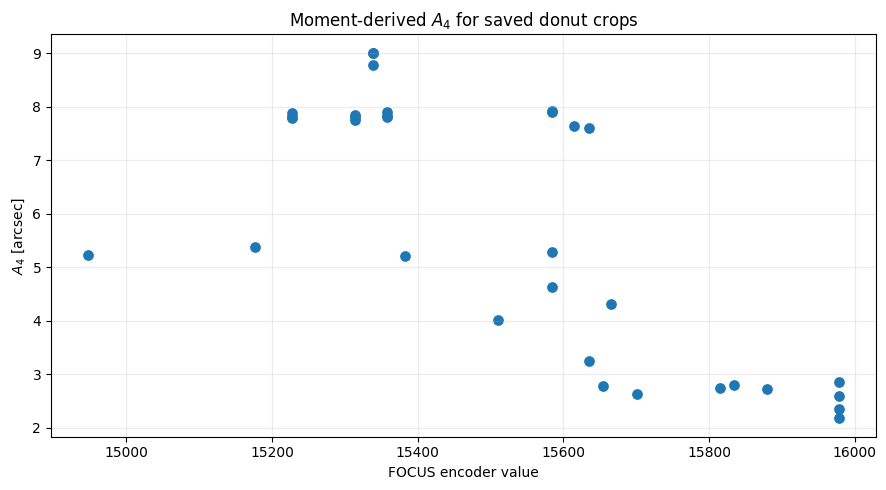

In [14]:
plt.figure(figsize=(9, 5))
plt.scatter(a4_table["focus"], a4_table["A4_arcsec"], s=45)
plt.xlabel("FOCUS encoder value")
plt.ylabel(r"$A_4$ [arcsec]")
plt.title(r"Moment-derived $A_4$ for saved donut crops")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Реализация формул (7) и (8)

Функции ниже реализуют систему из статьи. Здесь `A4_plus` и `A4_minus` должны быть положительными величинами `A4`, полученными из двух изображений по разные стороны от настоящего фокуса.

Если `α` неизвестен, сначала нужно либо:

1. взять его из калибровки телескопа;
2. либо оценить по отдельной серии измерений, где известна связь между изменением `FOCUS` и изменением `A4`.


In [15]:
def focus_from_equation_8(F_plus, F_minus, A4_plus, A4_minus, alpha):
    """
    Formula (8): true focus encoder setting F0.

    Parameters
    ----------
    F_plus, F_minus : float
        Encoder positions on the two sides of focus.
    A4_plus, A4_minus : float
        Positive focus parameters from the two donuts, in arcsec.
    alpha : float
        Calibration coefficient in arcsec per focus-encoder unit.
    """
    return 0.5 * (F_plus + F_minus) + (A4_minus - A4_plus) / (2.0 * alpha)


def seeing_bias_delta_from_equation_7(F_plus, F_minus, A4_plus, A4_minus, alpha, F0):
    """
    Estimate the seeing bias delta from both equations in (7), then average them.
    """
    delta_plus = A4_plus - alpha * (F_plus - F0)
    delta_minus = A4_minus - alpha * (F0 - F_minus)
    return 0.5 * (delta_plus + delta_minus)


def evaluate_equation_7_pair(F_plus, F_minus, A4_plus, A4_minus, alpha):
    """Convenience wrapper: compute F0 and delta for one bracketing pair."""
    F0 = focus_from_equation_8(F_plus, F_minus, A4_plus, A4_minus, alpha)
    delta = seeing_bias_delta_from_equation_7(F_plus, F_minus, A4_plus, A4_minus, alpha, F0)
    return F0, delta


## Выбор пары изображений

Ниже выбран пример пары из уже сохраненных crops. Это только стартовый пример: для настоящего применения нужно выбрать два изображения, которые действительно находятся по разные стороны от фокуса.

`alpha_arcsec_per_focus_unit` пока задан как демонстрационное значение. Его нужно заменить на калиброванное значение для конкретной системы.


In [16]:
# Example pair. Edit these paths when you choose a better bracketing pair.
plus_crop_dir = "processed/crops/Focus_r_2025-05-05T19-28-05_x1494_y1597_64"
minus_crop_dir = "processed/crops/Focus_r_2025-05-05T19-38-33_x1515_y1608_64"

# Demonstration alpha only. Replace this with telescope calibration.
alpha_arcsec_per_focus_unit = 0.0065

pair_rows = a4_table[a4_table["crop_dir"].isin([plus_crop_dir, minus_crop_dir])].copy()
pair_rows[["focus", "A4_arcsec", "seeing", "crop_dir"]]


,focus,A4_arcsec,seeing,crop_dir
23,15655.0,2.783137,4.9,processed/crops/Focus_r_2025-05-05T19-38-33_x1...
27,15835.0,2.791971,5.58,processed/crops/Focus_r_2025-05-05T19-28-05_x1...


In [17]:
if len(pair_rows) != 2:
    print("Choose two valid crop directories in plus_crop_dir and minus_crop_dir.")
else:
    plus_row = pair_rows[pair_rows["crop_dir"] == plus_crop_dir].iloc[0]
    minus_row = pair_rows[pair_rows["crop_dir"] == minus_crop_dir].iloc[0]

    F_plus = float(plus_row["focus"])
    F_minus = float(minus_row["focus"])
    A4_plus = float(plus_row["A4_arcsec"])
    A4_minus = float(minus_row["A4_arcsec"])

    # The formula assumes F_plus is the higher-focus side and F_minus is the lower-focus side.
    # Swap automatically if the example paths were assigned in the opposite order.
    if F_plus < F_minus:
        F_plus, F_minus = F_minus, F_plus
        A4_plus, A4_minus = A4_minus, A4_plus

    F0_demo, delta_demo = evaluate_equation_7_pair(
        F_plus=F_plus,
        F_minus=F_minus,
        A4_plus=A4_plus,
        A4_minus=A4_minus,
        alpha=alpha_arcsec_per_focus_unit,
    )

    print("Formula (8) demonstration")
    print(f"F+        = {F_plus:.1f}")
    print(f"F-        = {F_minus:.1f}")
    print(f"A4+       = {A4_plus:.4f} arcsec")
    print(f"A4-       = {A4_minus:.4f} arcsec")
    print(f"alpha     = {alpha_arcsec_per_focus_unit:.6f} arcsec/focus_unit  (demo calibration)")
    print(f"F0        = {F0_demo:.2f}")
    print(f"delta     = {delta_demo:.4f} arcsec")


Formula (8) demonstration
F+        = 15835.0
F-        = 15655.0
A4+       = 2.7920 arcsec
A4-       = 2.7831 arcsec
alpha     = 0.006500 arcsec/focus_unit  (demo calibration)
F0        = 15744.32
delta     = 2.2026 arcsec


## Зависимость результата от α

Так как `α` пока не калиброван, полезно посмотреть, насколько сильно оценка `F0` зависит от выбора `α`.


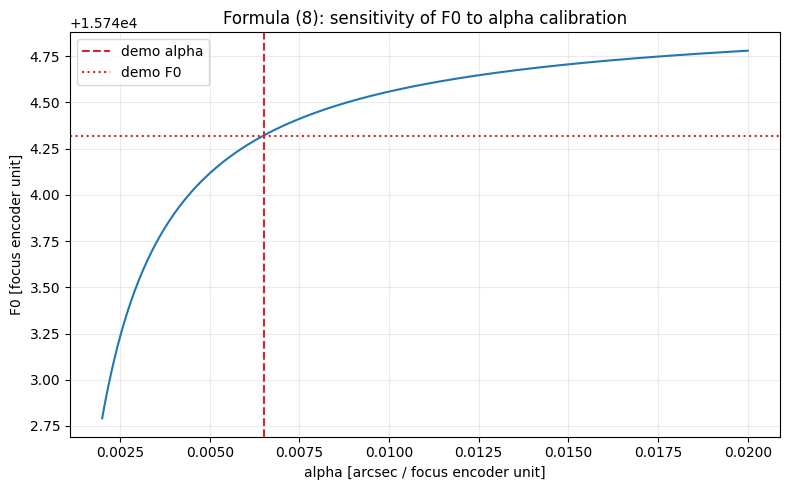

In [18]:
if len(pair_rows) == 2:
    alpha_grid = np.linspace(0.002, 0.02, 300)
    F0_grid = focus_from_equation_8(F_plus, F_minus, A4_plus, A4_minus, alpha_grid)

    plt.figure(figsize=(8, 5))
    plt.plot(alpha_grid, F0_grid)
    plt.axvline(alpha_arcsec_per_focus_unit, color="tab:red", linestyle="--", label="demo alpha")
    plt.axhline(F0_demo, color="tab:red", linestyle=":", label="demo F0")
    plt.xlabel("alpha [arcsec / focus encoder unit]")
    plt.ylabel("F0 [focus encoder unit]")
    plt.title("Formula (8): sensitivity of F0 to alpha calibration")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Экстраполяция от известного лучшего фокуса

Проверяем вашу текущую интерпретацию данных:

- `data/Focus_r_2025-05-05T18-38-41.fits` имеет `FOCUS = 15978` и рассматривается как лучший фокус `F0`.
- `data/Focus_r_2025-05-05T21-18-55.fits` имеет `FOCUS = 15339` и является расфокусированным изображением, которое анализируется в `main.ipynb`.

Здесь у нас не две стороны фокуса, поэтому формулу (8) напрямую применить нельзя. Вместо этого используем формулу (7) в одностороннем виде:

$$
A_4^- = lpha(F_0 - F^-) + \delta
$$

Если изображение при `FOCUS = 15978` действительно близко к лучшему фокусу, то его измеренный `A4` можно использовать как оценку `delta`, потому что при `F = F0` геометрический дефокус почти нулевой, а остаточная ширина в основном связана с seeing/PSF и предобработкой.

Тогда:

$$
lpha pprox 
rac{A_4^- - \delta}{F_0 - F^-}
$$


In [19]:
best_focus_crop_dir = "processed/crops/Focus_r_2025-05-05T18-38-41_x1394_y1568_64"
analyzed_crop_dir = "processed/crops/Focus_r_2025-05-05T21-18-55_x1596_y1688_64"

one_sided_rows = a4_table[
    a4_table["crop_dir"].isin([best_focus_crop_dir, analyzed_crop_dir])
].copy()

if len(one_sided_rows) != 2:
    raise RuntimeError(
        "Expected exactly two rows for the best-focus and analyzed crop directories. "
        "Run the A4 table cell first and check the crop paths."
    )

best_row = one_sided_rows[one_sided_rows["crop_dir"] == best_focus_crop_dir].iloc[0]
analyzed_row = one_sided_rows[one_sided_rows["crop_dir"] == analyzed_crop_dir].iloc[0]

F0_known = float(best_row["focus"])
F_minus_analyzed = float(analyzed_row["focus"])
A4_best_delta = float(best_row["A4_arcsec"])
A4_minus_analyzed = float(analyzed_row["A4_arcsec"])

focus_offset = F0_known - F_minus_analyzed
if focus_offset <= 0:
    raise RuntimeError("Expected the analyzed image to have lower FOCUS than the best-focus image.")

alpha_from_best_to_analyzed = (A4_minus_analyzed - A4_best_delta) / focus_offset

# Compare with the earlier demonstration alpha, if that variable already exists.
demo_alpha = globals().get("alpha_arcsec_per_focus_unit", np.nan)
demo_predicted_A4 = A4_best_delta + demo_alpha * focus_offset if np.isfinite(demo_alpha) else np.nan

def focus_from_one_sided_eq7(F_minus, A4_minus, delta, alpha):
    """Rearranged Eq. (7): F0 from one defocused image, if delta and alpha are known."""
    return F_minus + (A4_minus - delta) / alpha

F0_check_from_estimated_alpha = focus_from_one_sided_eq7(
    F_minus_analyzed,
    A4_minus_analyzed,
    A4_best_delta,
    alpha_from_best_to_analyzed,
)
F0_from_demo_alpha = (
    focus_from_one_sided_eq7(F_minus_analyzed, A4_minus_analyzed, A4_best_delta, demo_alpha)
    if np.isfinite(demo_alpha) and demo_alpha != 0
    else np.nan
)

print("One-sided Eq. (7) extrapolation")
print(f"Known/best focus F0             = {F0_known:.1f}")
print(f"Analyzed focus F-               = {F_minus_analyzed:.1f}")
print(f"Focus offset F0 - F-            = {focus_offset:.1f}")
print()
print(f"A4 at best focus, used as delta = {A4_best_delta:.4f} arcsec")
print(f"A4 at analyzed focus            = {A4_minus_analyzed:.4f} arcsec")
print(f"Estimated alpha                 = {alpha_from_best_to_analyzed:.6f} arcsec/focus_unit")
print(f"F0 from estimated alpha         = {F0_check_from_estimated_alpha:.2f}")
if np.isfinite(demo_predicted_A4):
    print(f"A4 predicted by demo alpha      = {demo_predicted_A4:.4f} arcsec")
    print(f"F0 from demo alpha              = {F0_from_demo_alpha:.2f}")

one_sided_rows[["focus", "A4_arcsec", "seeing", "masked_pixels", "crop_dir"]]


One-sided Eq. (7) extrapolation
Known/best focus F0             = 15978.0
Analyzed focus F-               = 15339.0
Focus offset F0 - F-            = 639.0

A4 at best focus, used as delta = 2.1748 arcsec
A4 at analyzed focus            = 9.0124 arcsec
Estimated alpha                 = 0.010700 arcsec/focus_unit
F0 from estimated alpha         = 15978.00
A4 predicted by demo alpha      = 6.3283 arcsec
F0 from demo alpha              = 16390.93


,focus,A4_arcsec,seeing,masked_pixels,crop_dir
10,15339.0,9.012373,3.86,2159,processed/crops/Focus_r_2025-05-05T21-18-55_x1...
29,15978.0,2.174802,UNKNOWN,931,processed/crops/Focus_r_2025-05-05T18-38-41_x1...


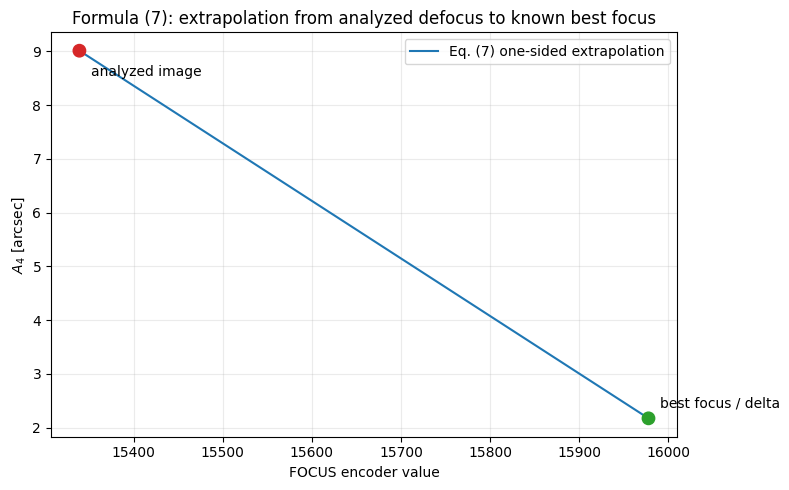

In [20]:
focus_grid = np.linspace(F_minus_analyzed, F0_known, 200)
A4_grid = A4_best_delta + alpha_from_best_to_analyzed * (F0_known - focus_grid)

plt.figure(figsize=(8, 5))
plt.plot(focus_grid, A4_grid, color="tab:blue", label="Eq. (7) one-sided extrapolation")
plt.scatter(
    [F0_known, F_minus_analyzed],
    [A4_best_delta, A4_minus_analyzed],
    s=80,
    color=["tab:green", "tab:red"],
    zorder=3,
)
plt.annotate("best focus / delta", (F0_known, A4_best_delta), xytext=(8, 8), textcoords="offset points")
plt.annotate("analyzed image", (F_minus_analyzed, A4_minus_analyzed), xytext=(8, -18), textcoords="offset points")
plt.xlabel("FOCUS encoder value")
plt.ylabel(r"$A_4$ [arcsec]")
plt.title("Formula (7): extrapolation from analyzed defocus to known best focus")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## Что нужно сделать дальше

1. Выбрать надежную пару изображений, которые находятся по разные стороны от истинного фокуса.
2. Откалибровать `α` для этой системы телескоп-детектор.
3. Подставить реальные `F+`, `F-`, `A4+`, `A4-` и `α` в формулу (8).
4. Проверить, что полученный `F0` физически находится между `F-` и `F+`.
5. Повторить расчет для нескольких пар и сравнить устойчивость оценки.
